In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [35]:
orders = pd.read_csv("Global Superstore.csv")

In [36]:
orders.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,Order Date,Order ID,Order Priority,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2010-01-01,CA-2011-130813,High,...,19,Consumer,2010-01-11,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2010-01-01,CA-2011-148614,Medium,...,19,Consumer,2010-01-02,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2010-01-01,CA-2011-118962,Medium,...,21,Consumer,2010-01-06,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2010-01-01,CA-2011-118962,Medium,...,111,Consumer,2010-01-04,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2010-01-01,CA-2011-146969,High,...,6,Consumer,2010-01-10,Standard Class,1.32,California,Paper,2011,North America,40


In [15]:
returns = pd.read_csv("Returns.csv")

In [18]:
returns.head()

,Order ID,Returned,Return Reason,Sales,Return Date,Refund Amount,Return Channel
0,CA-2012-167374,Yes,Late Delivery,17,26-08-26,12.118520,Store
1,CA-2012-167374,Yes,Late Delivery,40,12-09-26,30.837216,Online
2,IN-2011-67616,Yes,Customer Dissatisfaction,684,05-09-26,552.488632,Online
3,IN-2011-67616,Yes,Customer Dissatisfaction,198,28-08-26,169.619982,Online
4,IN-2011-67616,Yes,Customer Dissatisfaction,136,26-08-26,107.791850,Customer Service


In [37]:
merged = orders.merge(returns, on="Order ID", how="left", indicator=True)
merged["is_returned"] = merged["_merge"] == "both"

In [38]:
# Ensure both columns are datetime
merged["Order Date"] = pd.to_datetime(merged["Order Date"])
merged["Ship Date"] = pd.to_datetime(merged["Ship Date"])

In [39]:
# Create delivery_days column (difference in days)
merged["delivery_days"] = (merged["Ship Date"] - merged["Order Date"]).dt.days

In [40]:
# Quick check
print(merged[["Order Date", "Ship Date", "delivery_days"]].head())

  Order Date  Ship Date  delivery_days
0 2010-01-01 2010-01-11             10
1 2010-01-01 2010-01-02              1
2 2010-01-01 2010-01-06              5
3 2010-01-01 2010-01-04              3
4 2010-01-01 2010-01-10              9


In [70]:
# Assuming delivery days represent the number of days product was kept in inventory
corr = merged[["delivery_days", "Profit"]].corr()
print(corr)

               delivery_days    Profit
delivery_days       1.000000 -0.001495
Profit             -0.001495  1.000000


In [42]:
# Select only numeric columns
numeric_df = merged.select_dtypes(include=["number"])

In [59]:
corr = numeric_df.corr()

In [62]:
# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

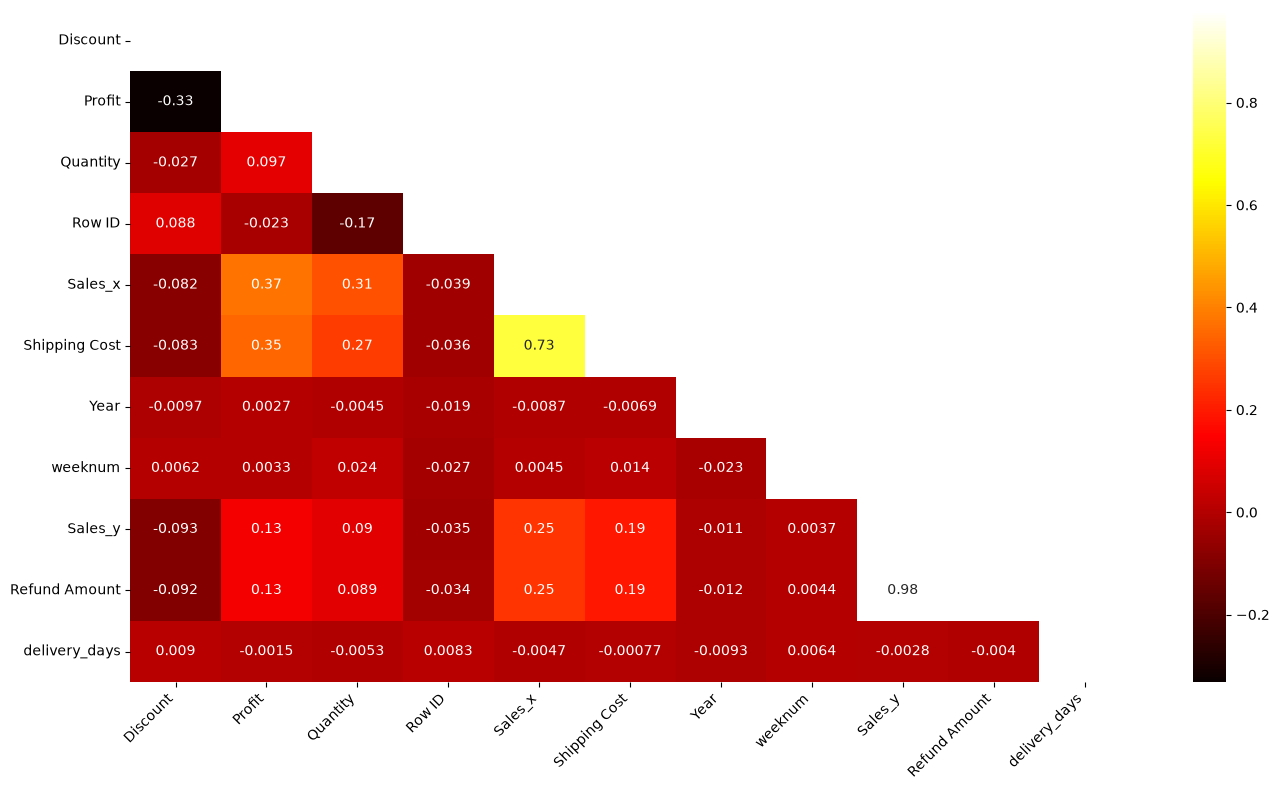

In [68]:
# Correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap="hot", annot_kws={"size":10})
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
slow_movers = merged.groupby("Category")["delivery_days"].mean().sort_values(ascending=False)
print(slow_movers)

Category
Furniture          5.500683
Office Supplies    5.499321
Technology         5.433520
Name: delivery_days, dtype: float64
